In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv("PizzaHut.csv")

df.head()

,site,lat,lng,zip,name,address,phone,email,web
0,PizzaHut,57.150313,-2.077635,AB24 5EN,Aberdeen Beach,"Unit 4, Queens Links Leisure Park, Aberdeen, A...",01224 592345,NaN,https://www.pizzahut.co.uk/huts/uk-2/377-aberdeen
1,PizzaHut,57.144619,-2.098275,AB11 5RG,Aberdeen Union Square,"Unit FS18, 11 First Level Mall, Aberdeen, Scot...",01224 569990,NaN,https://www.pizzahut.co.uk/huts/uk-2/994-aberdeen
2,PizzaHut,50.787499,0.302947,BN23 6QD,Admiral Retail Park,"Admiral Retail Park, Lott Bridge Drove, Eastbo...",01323 412008,NaN,https://www.pizzahut.co.uk/huts/uk-2/732-eastb...
3,PizzaHut,53.479733,-2.952935,L9 5AL,Aintree,"Aintree Racecourse & Business Park, Topham Dri...",0151 525 0019,NaN,https://www.pizzahut.co.uk/huts/uk-2/367-aintree
4,PizzaHut,51.177414,-1.758054,SP4 7SQ,Amesbury,"Solstice Park, Amesbury, Wiltshire, England, S...",1980676200,NaN,https://www.pizzahut.co.uk/huts/uk-2/967-amesbury


In [3]:
print(df.shape)
print(df.info())
print(df.describe())

(150, 9)
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   site     150 non-null    str    
 1   lat      150 non-null    float64
 2   lng      150 non-null    float64
 3   zip      150 non-null    str    
 4   name     150 non-null    str    
 5   address  150 non-null    str    
 6   phone    150 non-null    str    
 7   email    0 non-null      float64
 8   web      150 non-null    str    
dtypes: float64(3), str(6)
memory usage: 35.1 KB
None
              lat         lng  email
count  150.000000  150.000000    0.0
mean    52.962472   -1.507145    NaN
std      1.545560    1.437137    NaN
min     50.264275   -5.103265    NaN
25%     51.573860   -2.596239    NaN
50%     52.686004   -1.555379    NaN
75%     53.722448   -0.354921    NaN
max     57.481922    1.723050    NaN


In [5]:
df.select_dtypes(include=['object', 'string'])

,site,zip,name,address,phone,web
0,PizzaHut,AB24 5EN,Aberdeen Beach,"Unit 4, Queens Links Leisure Park, Aberdeen, A...",01224 592345,https://www.pizzahut.co.uk/huts/uk-2/377-aberdeen
1,PizzaHut,AB11 5RG,Aberdeen Union Square,"Unit FS18, 11 First Level Mall, Aberdeen, Scot...",01224 569990,https://www.pizzahut.co.uk/huts/uk-2/994-aberdeen
2,PizzaHut,BN23 6QD,Admiral Retail Park,"Admiral Retail Park, Lott Bridge Drove, Eastbo...",01323 412008,https://www.pizzahut.co.uk/huts/uk-2/732-eastb...
3,PizzaHut,L9 5AL,Aintree,"Aintree Racecourse & Business Park, Topham Dri...",0151 525 0019,https://www.pizzahut.co.uk/huts/uk-2/367-aintree
4,PizzaHut,SP4 7SQ,Amesbury,"Solstice Park, Amesbury, Wiltshire, England, S...",1980676200,https://www.pizzahut.co.uk/huts/uk-2/967-amesbury
...,...,...,...,...,...,...
145,PizzaHut,WN5 0UJ,Wigan,"No. 2 Anjou Boulevard, Robin Park, Wigan, Lanc...",01942 215826,https://www.pizzahut.co.uk/huts/uk-2/366-wigan
146,PizzaHut,LL13 7SU,Wrexham Retail Park,"Wrexham Central Retail Park, Central Road, Wre...",01978 353 400,https://www.pizzahut.co.uk/huts/uk-2/963-wrexham
147,PizzaHut,HP11 1FY,Wycombe Retail Park,"Wycombe Retail Park, Ryemead Way, High Wycombe...",01494 538886,https://www.pizzahut.co.uk/huts/uk-2/779-high-...
148,PizzaHut,BA20 1NP,Yeovil,"Unit 4 Old Town Station Leisure Park, Old Stat...",01935 706 606,https://www.pizzahut.co.uk/huts/uk-2/463-yeovil


In [7]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for col in df.select_dtypes(include=['object', 'string']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [8]:
X = df.iloc[:, :-1]   # all columns except last
y = df.iloc[:, -1]    # last column as target

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
set(y_train.unique()) - set(y_test.unique())
set(y_test.unique()) - set(y_train.unique())

{np.int64(3),
 np.int64(11),
 np.int64(12),
 np.int64(18),
 np.int64(19),
 np.int64(25),
 np.int64(31),
 np.int64(34),
 np.int64(36),
 np.int64(41),
 np.int64(42),
 np.int64(51),
 np.int64(68),
 np.int64(76),
 np.int64(80),
 np.int64(90),
 np.int64(98),
 np.int64(102),
 np.int64(107),
 np.int64(111),
 np.int64(115),
 np.int64(119),
 np.int64(123),
 np.int64(124),
 np.int64(132),
 np.int64(133),
 np.int64(140),
 np.int64(142),
 np.int64(147),
 np.int64(149)}

In [13]:
print(y.nunique())
print(y.value_counts().head(20))

150
web
37     1
148    1
97     1
32     1
136    1
7      1
52     1
29     1
139    1
42     1
47     1
20     1
107    1
55     1
129    1
14     1
9      1
64     1
36     1
18     1
Name: count, dtype: int64


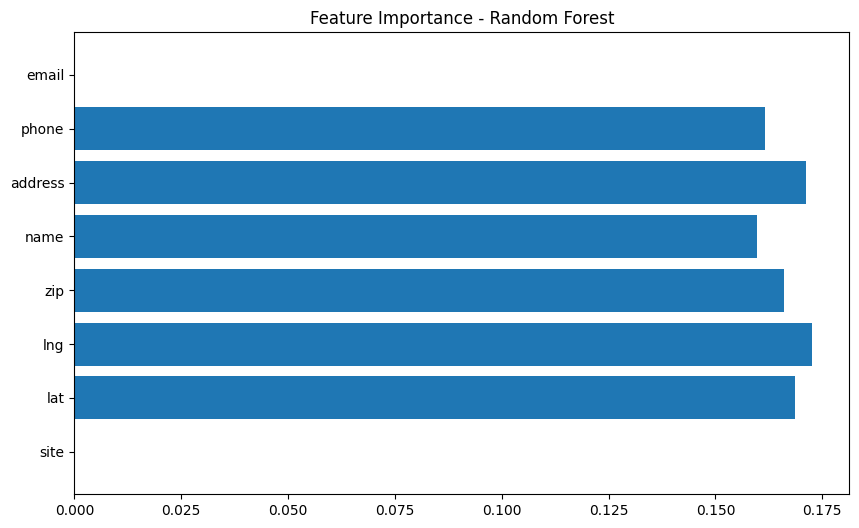

In [14]:
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_
features = X.columns

plt.figure(figsize=(10,6))
plt.barh(features, importances)
plt.title("Feature Importance - Random Forest")
plt.show()